# HAT Layer 1 — Multi-Feature Clustering

**Purpose:** Cluster emotional vs neutral trials using only Layer 1 (INAC) features.

**Structure:**
- §1 Imports and configuration
- §2 Load and prepare data
- §3 Select L1 features
- §4 Single-feature clustering (ranks features by accuracy)
- §5 Multi-feature clustering sweep (top-N by single-feature accuracy)
- §6 PCA visualisation of best configuration
- §7 Summary

## §1 — Imports and configuration

In [9]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
# DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'
DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'

RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
# Add or remove run labels here as new data arrives
RUNS = ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3','4']

# ── Active L1 indicators (non-zero across all trials) ─────────────────────────
# Zero-count indicators (hat_SPU, hat_MCE, ECC) are excluded automatically
# by the NaN/zero-variance drop below.
L1_INDICATORS = [
    'hat_TLB',
    'tlb:tlb_flush',
    'core_power.throttle',
]

ALL_METRICS = [
    'mean_rate', 'variance', 'p90_p10', 'slope',
    'spectral_entropy', 'iat_cv', 'burst_rate',
    'burst_clustering', 'lz_complexity', 'perm_entropy',
]

# ── Clustering config ──────────────────────────────────────────────────────────
RAND_SEED  = 42
N_INIT     = 50        # KMeans restarts
MAX_N      = 15        # maximum N for the sweep

print('Configuration OK')
print(f'  Runs        : {RUNS}')
print(f'  L1 active   : {L1_INDICATORS}')
print(f'  Max sweep N : {MAX_N}')

Configuration OK
  Runs        : ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  L1 active   : ['hat_TLB', 'tlb:tlb_flush', 'core_power.throttle']
  Max sweep N : 15


## §2 — Load and prepare data

In [10]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
# DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'
DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'

RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
# Add or remove run labels here as new data arrives
RUNS = ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3','4']



# ── n-D clustering config ─────────────────────────────────────────────────────
# Number of top features (by composite rank) to use in the multi-feature KMeans

# ── Layer 1 indicators (HAT definition named types) ───────────────────────────
# These come from /proc/interrupts (hat_ prefix) and perf tracepoints
HAT_L1 = {
    'hat_SPU':            'Spurious interrupt',
    'hat_MCE':            'Machine Check Exception',
    'hat_TLB':            'TLB Shootdown (IPI)',
    'tlb:tlb_flush':      'TLB Shootdown (tracepoint, 1ms)',
    'mce:mce_record':     'MCE tracepoint',
    'core_power.throttle':'Thermal/Power Anomaly',
    'uncore_imc/UNC_M_ECC_CORRECTABLE_ERRORS/': 'ECC Correctable Error',
}

# ── Layer 2 indicators (continuous performance metrics) ───────────────────────
HAT_L2 = {
    'uncore_imc/cas_count_read/':  'DRAM read bandwidth (CAS)',
    'uncore_imc/cas_count_write/': 'DRAM write bandwidth (CAS)',
    'dTLB-load-misses':   'dTLB load misses (weight tensor pressure)',
    'cache-misses':        'LLC cache misses → DRAM fetches',
    'cache-references':    'LLC cache references',
    'LLC-load-misses':     'LLC load misses',
    'cycles':              'CPU cycles',
    'instructions':        'Retired instructions',
    'stalled-cycles-frontend': 'Frontend pipeline stalls',
    'stalled-cycles-backend':  'Backend pipeline stalls',
    'branch-instructions': 'Total branches',
    'power/energy-pkg/':   'Package energy (RAPL)',
    'power/energy-ram/':   'DRAM energy (RAPL)',
}

# ── Confounder indicators (collected for context, NOT used in clustering) ──────
CONFOUNDERS = {
    'context-switches': 'Context switches (scheduling artefact)',
    'cpu-migrations':   'CPU migrations (load balancer)',
    'page-faults':      'Page faults (mmap / memory management)',
    'cpu-clock':        'CPU time (duration normaliser)',
    'cpu_freq_mean':    'CPU frequency mean (DVFS governor)',
    'sched:sched_stat_wait': 'Scheduler wait-time (run-queue delay)',
}

# ── Indicators to exclude from all analysis ────────────────────────────────────
EXCLUDE_INDICATORS = {
    'hat_PMI', 'hat_NMI',   # perf's own sampling interrupts — artefact
    'hat_LOC', 'hat_RES', 'hat_CAL', 'hat_MCP',  # fixed-rate OS housekeeping
    'branch-misses',
    'msr/cpu_thermal_margin/',
}

ALL_METRICS = [
    'mean_rate', 'variance', 'p90_p10', 'slope',
    'spectral_entropy', 'iat_cv', 'burst_rate',
    'burst_clustering', 'lz_complexity', 'perm_entropy'
]

print(f'Configuration OK')
print(f'  Runs: {RUNS}')
print(f'  L1 indicators: {len(HAT_L1)}')
print(f'  L2 indicators: {len(HAT_L2)}')
print(f'  Confounders:   {len(CONFOUNDERS)}')
dfs_by_run = {}
loaded, missing = [], []

for run in RUNS:
    p = DATA_DIR / f'independent{run}.csv'
    if p.exists():
        df = pd.read_csv(p)
        df['run'] = run
        dfs_by_run[run] = df
        loaded.append(run)
    else:
        missing.append(run)

if missing:
    print(f'⚠  Not found (skipping): {missing}')

RUNS_LOADED = loaded
df_all = pd.concat([dfs_by_run[r] for r in RUNS_LOADED], ignore_index=True)
y_true = (df_all['condition'] == 'emotional').astype(int).values

print(f'Loaded {len(RUNS_LOADED)} runs: {RUNS_LOADED}')
print(f'  Total trials : {len(df_all)}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Run counts   : {df_all["run"].value_counts().sort_index().to_dict()}')
print(f'  Feature cols : {len([c for c in df_all.columns if "__" in c])}')

Configuration OK
  Runs: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  L1 indicators: 7
  L2 indicators: 13
  Confounders:   6
Loaded 12 runs: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Total trials : 480
  Neutral      : 240
  Emotional    : 240
  Run counts   : {'1': 40, '2': 40, '3': 40, '4': 40, 'A': 40, 'AA': 40, 'AB': 40, 'AC': 40, 'B': 40, 'D': 40, 'E': 40, 'F': 40}
  Feature cols : 580


## §3 — Select L1 features

In [11]:
def indicator_of(col: str) -> str:
    """Return the indicator name from a column like 'hat_TLB__mean_rate'."""
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

# Collect all columns belonging to active L1 indicators
l1_cols = [
    c for c in df_all.columns
    if indicator_of(c) in L1_INDICATORS
]

X_l1 = df_all[l1_cols].copy()

# Drop all-NaN columns (e.g. iat_cv for indicators with no events)
before = X_l1.shape[1]
X_l1 = X_l1.dropna(axis=1, how='all')
print(f'Dropped {before - X_l1.shape[1]} all-NaN columns')

# Fill remaining NaNs with column median
X_l1 = X_l1.fillna(X_l1.median())

# Drop zero-variance columns (zero-count indicators produce constant zeros)
before = X_l1.shape[1]
X_l1 = X_l1.loc[:, X_l1.std() > 0]
print(f'Dropped {before - X_l1.shape[1]} zero-variance columns')

print(f'L1 features available for clustering: {X_l1.shape[1]}')
print(X_l1.columns.tolist())

Dropped 0 all-NaN columns
Dropped 0 zero-variance columns
L1 features available for clustering: 30
['tlb:tlb_flush__mean_rate', 'tlb:tlb_flush__variance', 'tlb:tlb_flush__p90_p10', 'tlb:tlb_flush__slope', 'tlb:tlb_flush__spectral_entropy', 'tlb:tlb_flush__iat_cv', 'tlb:tlb_flush__burst_rate', 'tlb:tlb_flush__burst_clustering', 'tlb:tlb_flush__lz_complexity', 'tlb:tlb_flush__perm_entropy', 'core_power.throttle__mean_rate', 'core_power.throttle__variance', 'core_power.throttle__p90_p10', 'core_power.throttle__slope', 'core_power.throttle__spectral_entropy', 'core_power.throttle__iat_cv', 'core_power.throttle__burst_rate', 'core_power.throttle__burst_clustering', 'core_power.throttle__lz_complexity', 'core_power.throttle__perm_entropy', 'hat_TLB__mean_rate', 'hat_TLB__variance', 'hat_TLB__p90_p10', 'hat_TLB__slope', 'hat_TLB__spectral_entropy', 'hat_TLB__iat_cv', 'hat_TLB__burst_rate', 'hat_TLB__burst_clustering', 'hat_TLB__lz_complexity', 'hat_TLB__perm_entropy']


## §4 — Single-feature clustering

For each L1 feature independently: standardise, run KMeans k=2, align clusters
to ground truth by majority vote, record accuracy and ARI.
This ranking is then used to select features for the multi-feature sweep.

In [12]:
def kmeans_accuracy_ari(X: np.ndarray, y: np.ndarray, n_init: int = 50,
                         seed: int = 42) -> tuple[float, float]:
    """
    Fit KMeans k=2, align predicted clusters to ground truth by majority vote,
    return (accuracy, ARI).
    """
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)

    # Majority-vote alignment: pick label assignment that maximises accuracy
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc_straight = (cm[0, 0] + cm[1, 1]) / cm.sum()
    acc_flipped  = (cm[0, 1] + cm[1, 0]) / cm.sum()
    acc = max(acc_straight, acc_flipped)
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


records = []
for col in X_l1.columns:
    X_feat = X_l1[[col]].values
    acc, ari = kmeans_accuracy_ari(X_feat, y_true, n_init=N_INIT, seed=RAND_SEED)
    records.append({
        'feature':   col,
        'indicator': indicator_of(col),
        'metric':    col.split('__')[-1],
        'accuracy':  acc,
        'ari':       ari,
    })

sf_results = pd.DataFrame(records).sort_values('accuracy', ascending=False).reset_index(drop=True)

print(f'Single-feature clustering results (ranked by accuracy):')
print(sf_results[['feature', 'accuracy', 'ari']].to_string(index=False))

Single-feature clustering results (ranked by accuracy):
                              feature  accuracy       ari
       core_power.throttle__mean_rate  0.543750  0.005580
core_power.throttle__spectral_entropy  0.541667  0.004876
      tlb:tlb_flush__burst_clustering  0.535417  0.003038
                  hat_TLB__burst_rate  0.531250  0.001835
      core_power.throttle__burst_rate  0.527083  0.000850
                 tlb:tlb_flush__slope  0.527083  0.001263
                   hat_TLB__mean_rate  0.527083  0.001162
             tlb:tlb_flush__mean_rate  0.525000  0.000806
               hat_TLB__lz_complexity  0.525000  0.000591
core_power.throttle__burst_clustering  0.525000  0.000544
                tlb:tlb_flush__iat_cv  0.522917  0.000015
            tlb:tlb_flush__burst_rate  0.522917  0.001658
            hat_TLB__burst_clustering  0.518750  0.000933
           core_power.throttle__slope  0.518750 -0.000382
            hat_TLB__spectral_entropy  0.516667 -0.000920
                

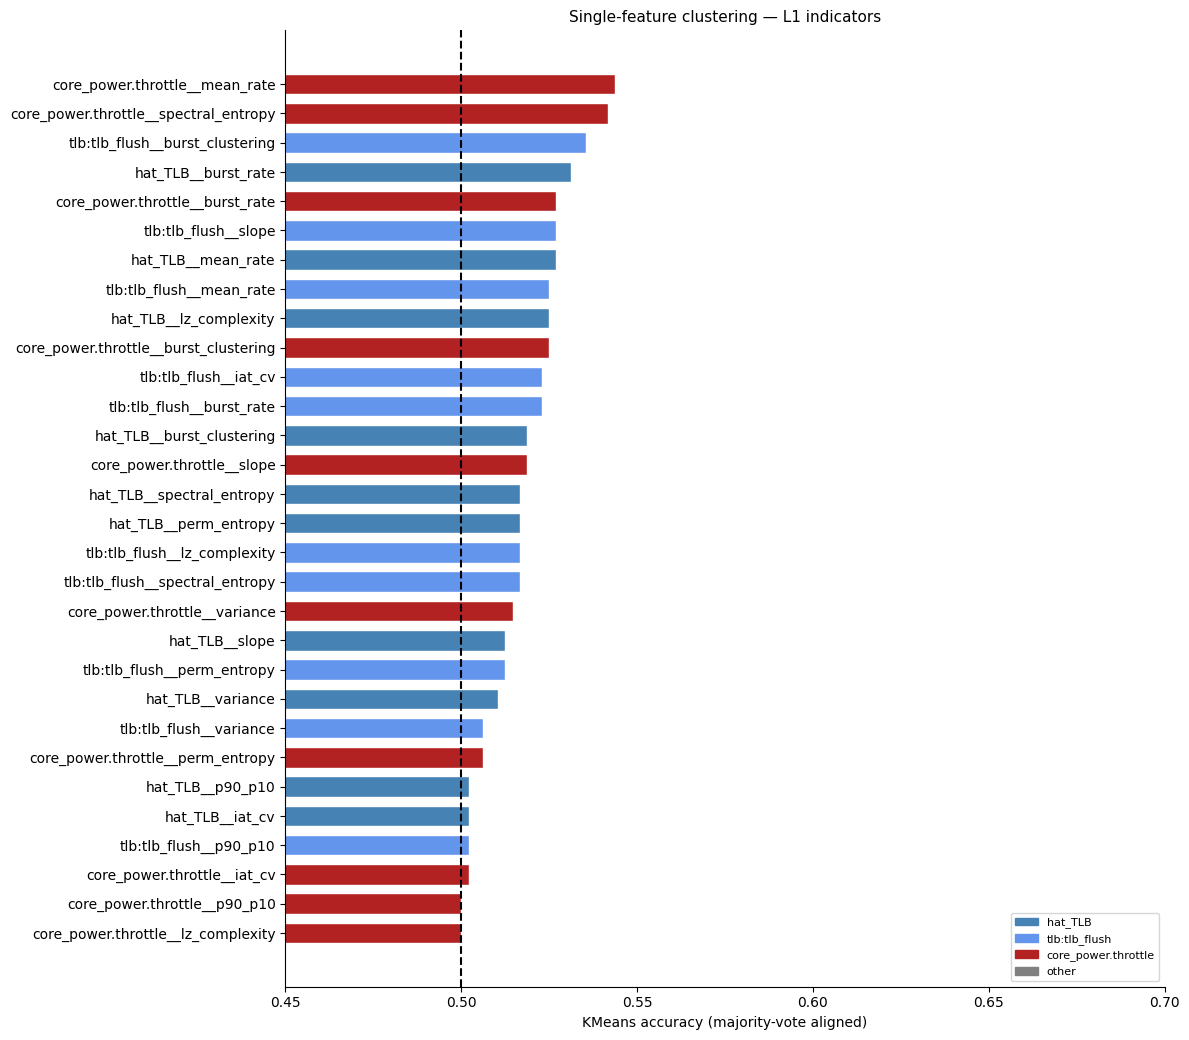

In [13]:
# ── Plot: single-feature accuracy bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(4, len(sf_results) * 0.35)))

colors = {
    'hat_TLB':            'steelblue',
    'tlb:tlb_flush':      'cornflowerblue',
    'core_power.throttle':'firebrick',
}
bar_colors = [colors.get(r.indicator, 'grey') for _, r in sf_results.iterrows()]

bars = ax.barh(sf_results['feature'], sf_results['accuracy'],
               color=bar_colors, edgecolor='white', height=0.7)
ax.axvline(0.5, color='black', lw=1.5, ls='--', label='Chance (0.50)')
ax.set_xlabel('KMeans accuracy (majority-vote aligned)', fontsize=10)
ax.set_title('Single-feature clustering — L1 indicators', fontsize=11)
ax.set_xlim(0.45, 0.70)
ax.invert_yaxis()

# Legend
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
legend_patches.append(mpatches.Patch(color='grey', label='other'))
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULT_DIR / 'single_feature_accuracy.png', bbox_inches='tight')
plt.show()

## §5 — Multi-feature clustering sweep

For N = 1 … MAX_N, take the top-N features ranked by single-feature accuracy,
standardise jointly, run KMeans k=2, and record accuracy and ARI.
This shows whether combining features improves separation.

In [14]:
ranked_features = sf_results['feature'].tolist()
max_n = min(MAX_N, len(ranked_features))

sweep = []
for n in range(1, max_n + 1):
    selected = ranked_features[:n]
    X_n = X_l1[selected].values
    acc, ari = kmeans_accuracy_ari(X_n, y_true, n_init=N_INIT, seed=RAND_SEED)
    sweep.append({'n_features': n, 'accuracy': acc, 'ari': ari,
                  'features': selected})
    print(f'  N={n:2d}  acc={acc:.4f}  ARI={ari:.4f}  features: {selected}')

sweep_df = pd.DataFrame(sweep)
best_row = sweep_df.loc[sweep_df['accuracy'].idxmax()]
print(f'\nBest N: {int(best_row.n_features)}  '
      f'acc={best_row.accuracy:.4f}  ARI={best_row.ari:.4f}')
print(f'Features used: {best_row.features}')

  N= 1  acc=0.5437  ARI=0.0056  features: ['core_power.throttle__mean_rate']
  N= 2  acc=0.5354  ARI=0.0031  features: ['core_power.throttle__mean_rate', 'core_power.throttle__spectral_entropy']
  N= 3  acc=0.5229  ARI=0.0004  features: ['core_power.throttle__mean_rate', 'core_power.throttle__spectral_entropy', 'tlb:tlb_flush__burst_clustering']
  N= 4  acc=0.5271  ARI=0.0009  features: ['core_power.throttle__mean_rate', 'core_power.throttle__spectral_entropy', 'tlb:tlb_flush__burst_clustering', 'hat_TLB__burst_rate']
  N= 5  acc=0.5250  ARI=0.0004  features: ['core_power.throttle__mean_rate', 'core_power.throttle__spectral_entropy', 'tlb:tlb_flush__burst_clustering', 'hat_TLB__burst_rate', 'core_power.throttle__burst_rate']
  N= 6  acc=0.5312  ARI=0.0019  features: ['core_power.throttle__mean_rate', 'core_power.throttle__spectral_entropy', 'tlb:tlb_flush__burst_clustering', 'hat_TLB__burst_rate', 'core_power.throttle__burst_rate', 'tlb:tlb_flush__slope']
  N= 7  acc=0.5375  ARI=0.0038

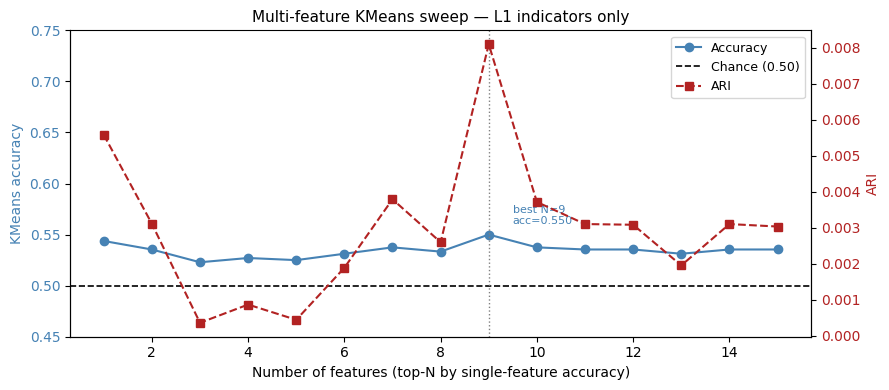

In [15]:
# ── Plot: accuracy and ARI vs N ────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.plot(sweep_df.n_features, sweep_df.accuracy,
         marker='o', color='steelblue', label='Accuracy')
ax1.axhline(0.5, color='black', lw=1.2, ls='--', label='Chance (0.50)')
ax1.set_xlabel('Number of features (top-N by single-feature accuracy)', fontsize=10)
ax1.set_ylabel('KMeans accuracy', fontsize=10, color='steelblue')
ax1.set_ylim(0.45, 0.75)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(sweep_df.n_features, sweep_df.ari,
         marker='s', color='firebrick', ls='--', label='ARI')
ax2.set_ylabel('ARI', fontsize=10, color='firebrick')
ax2.tick_params(axis='y', labelcolor='firebrick')

# Mark best N
ax1.axvline(best_row.n_features, color='grey', lw=1.0, ls=':')
ax1.annotate(f'best N={int(best_row.n_features)}\nacc={best_row.accuracy:.3f}',
             xy=(best_row.n_features, best_row.accuracy),
             xytext=(best_row.n_features + 0.5, best_row.accuracy + 0.01),
             fontsize=8, color='steelblue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

ax1.set_title('Multi-feature KMeans sweep — L1 indicators only', fontsize=11)
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'sweep_accuracy_ari.png', bbox_inches='tight')
plt.show()

## §6 — PCA visualisation of best configuration

Project the best-N feature set to 2 principal components
and colour points by true condition label.

PC1: 48.7%   PC2: 19.7%


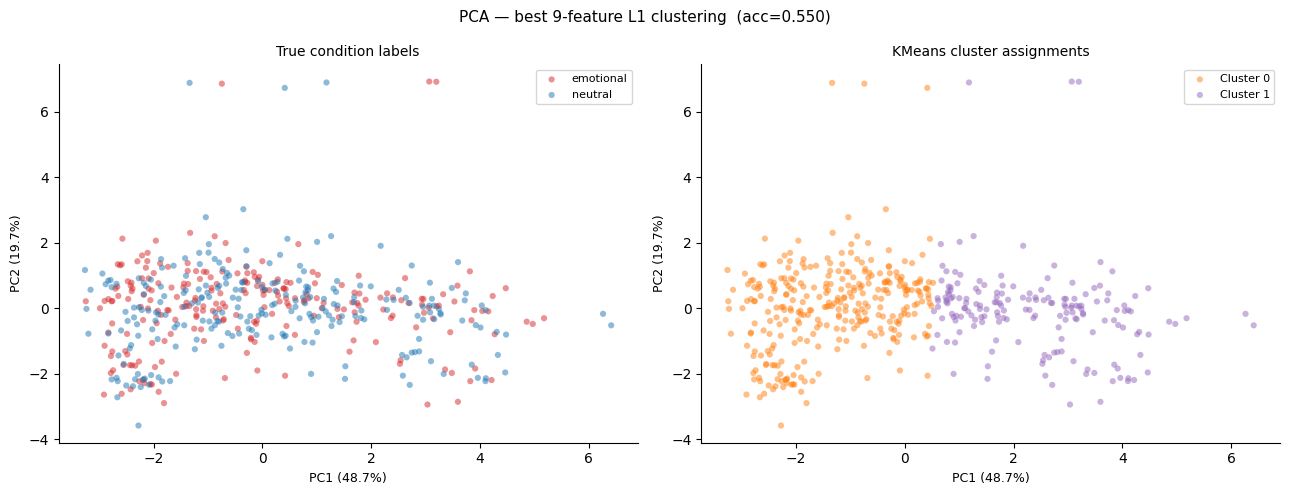

In [16]:
best_features = best_row.features
X_best = X_l1[best_features].values

scaler = StandardScaler()
X_best_s = scaler.fit_transform(X_best)

pca = PCA(n_components=2, random_state=RAND_SEED)
coords = pca.fit_transform(X_best_s)
var_exp = pca.explained_variance_ratio_ * 100
print(f'PC1: {var_exp[0]:.1f}%   PC2: {var_exp[1]:.1f}%')

# Also get KMeans cluster assignments for the best config
km_best = KMeans(n_clusters=2, n_init=N_INIT, random_state=RAND_SEED)
km_pred = km_best.fit_predict(X_best_s)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: true condition labels
ax = axes[0]
for cond, color in [('emotional', 'tab:red'), ('neutral', 'tab:blue')]:
    mask = df_all['condition'].values == cond
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=color, label=cond, alpha=0.5, edgecolors='none', s=20)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', fontsize=9)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', fontsize=9)
ax.set_title('True condition labels', fontsize=10)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Right: KMeans cluster assignments
ax = axes[1]
for cluster, color in [(0, 'tab:orange'), (1, 'tab:purple')]:
    mask = km_pred == cluster
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=color, label=f'Cluster {cluster}', alpha=0.5,
               edgecolors='none', s=20)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', fontsize=9)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', fontsize=9)
ax.set_title('KMeans cluster assignments', fontsize=10)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    f'PCA — best {int(best_row.n_features)}-feature L1 clustering  '
    f'(acc={best_row.accuracy:.3f})',
    fontsize=11
)
plt.tight_layout()
plt.savefig(RESULT_DIR / 'pca_best_config.png', bbox_inches='tight')
plt.show()

## §7 — Summary

In [18]:
print('=' * 70)
print('L1 MULTI-FEATURE CLUSTERING SUMMARY')
print('=' * 70)
print(f'Trials          : {len(df_all)} ({len(RUNS_LOADED)} runs)')
print(f'L1 features     : {X_l1.shape[1]} (after NaN/zero-variance drop)')
print()
print('Single-feature results (top 5 by accuracy):')
print(sf_results[['feature', 'accuracy', 'ari']].head(5).to_string(index=False))
print()
print('Multi-feature sweep:')
print(sweep_df[['n_features', 'accuracy', 'ari']].to_string(index=False))
print()
print(f'Best configuration:')
print(f'  N features : {int(best_row.n_features)}')
print(f'  Accuracy   : {best_row.accuracy:.4f}')
print(f'  ARI        : {best_row.ari:.4f}')
print(f'  Features   : {best_row.features}')
print(f'  Chance     : 0.5000')
print(f'  Above chance: {best_row.accuracy > 0.50}')

L1 MULTI-FEATURE CLUSTERING SUMMARY
Trials          : 480 (12 runs)
L1 features     : 30 (after NaN/zero-variance drop)

Single-feature results (top 5 by accuracy):
                              feature  accuracy      ari
       core_power.throttle__mean_rate  0.543750 0.005580
core_power.throttle__spectral_entropy  0.541667 0.004876
      tlb:tlb_flush__burst_clustering  0.535417 0.003038
                  hat_TLB__burst_rate  0.531250 0.001835
      core_power.throttle__burst_rate  0.527083 0.000850

Multi-feature sweep:
 n_features  accuracy      ari
          1  0.543750 0.005580
          2  0.535417 0.003108
          3  0.522917 0.000355
          4  0.527083 0.000861
          5  0.525000 0.000438
          6  0.531250 0.001883
          7  0.537500 0.003788
          8  0.533333 0.002594
          9  0.550000 0.008095
         10  0.537500 0.003712
         11  0.535417 0.003098
         12  0.535417 0.003080
         13  0.531250 0.001949
         14  0.535417 0.003098
      